In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("dataset/student_exam_performance_dataset.csv")
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [3]:
df = df.drop(columns=["student_id", "math_score", "reading_score", "writing_score", "science_score", "final_exam_score"])

In [4]:
df.head()

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,previous_gpa,pass_fail,grade_category
0,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,2.44,Fail,F
1,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,2.79,Pass,C
2,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,1.49,Fail,F
3,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,3.5,63.5,72.9,4,No,1.34,Fail,F
4,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,2.1,71.8,55.7,0,No,2.60,Pass,C


In [5]:
X = df.drop(columns=["pass_fail", "grade_category"])
y = df["pass_fail"]

In [6]:
print(X.columns)

Index(['gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'study_hours_per_day',
       'attendance_rate', 'sleep_hours', 'social_media_hours',
       'assignment_completion_rate', 'participation_score',
       'online_courses_completed', 'tutoring', 'previous_gpa'],
      dtype='object')


In [7]:
X = pd.get_dummies(X, drop_first=True)

In [8]:
X.head()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,previous_gpa,gender_Male,parental_education_High School,parental_education_Master,parental_education_PhD,family_income_Low,family_income_Medium,internet_access_Yes,study_environment_Noisy,study_environment_Quiet,tutoring_Yes
0,17,2.98,96.5,6.05,0.1,80.5,68.7,1,2.44,True,True,False,False,False,True,True,False,True,True
1,18,4.45,95.7,6.96,2.9,70.9,92.6,0,2.79,False,True,False,False,True,False,True,False,True,True
2,17,3.75,76.0,7.02,2.4,77.6,45.8,4,1.49,True,True,False,False,False,True,False,False,True,True
3,18,2.03,72.6,6.23,3.5,63.5,72.9,4,1.34,True,False,False,False,False,True,True,False,True,False
4,18,5.14,87.3,8.54,2.1,71.8,55.7,0,2.60,True,False,False,False,False,True,True,False,True,False


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [11]:
model = LogisticRegression(max_iter=1000)

In [12]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test)

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[929 141]
 [137 793]]


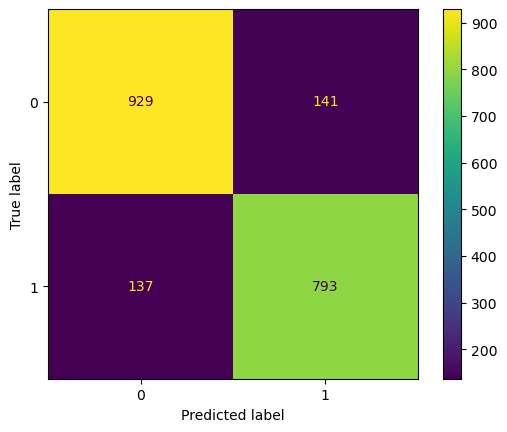

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Fail       0.87      0.87      0.87      1070
        Pass       0.85      0.85      0.85       930

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

